# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset

In [ ]:
df = pd.read_csv('/content/bank-additional-full_final (3).csv')

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  campaign        41188 non-null  int64  
 11  pdays           41188 non-null  int64  
 12  previous        41188 non-null  int64  
 13  poutcome        41188 non-null  object 
 14  emp.var.rate    41188 non-null  float64
 15  cons.price.idx  41188 non-null  float64
 16  cons.conf.idx   41188 non-null  float64
 17  euribor3m       41188 non-null 

# EDA - Exploratory Data Analysis

1. Null values
2. Duplicate values
3. Outliers
4. Label encoding

In [ ]:
# Null Values

df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [ ]:
# Duplicated Values

df.duplicated().sum()

np.int64(1784)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.duplicated().sum()

np.int64(0)

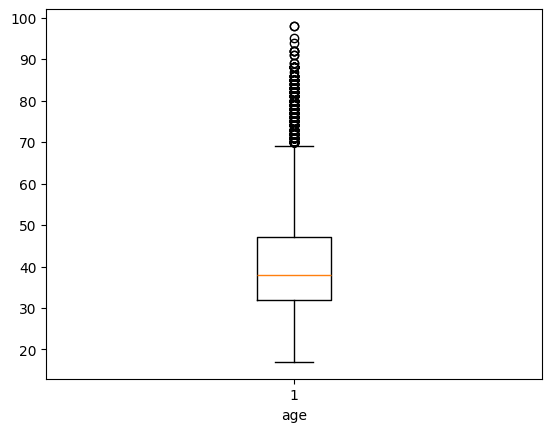

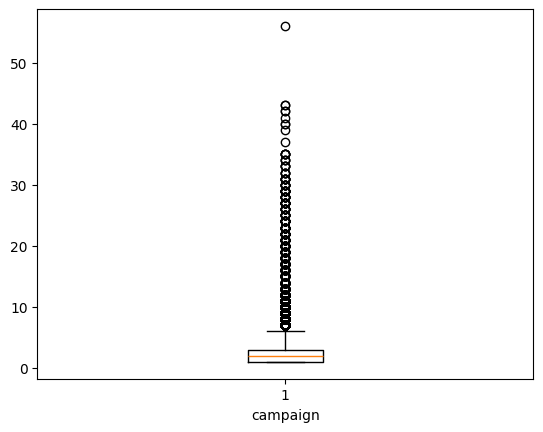

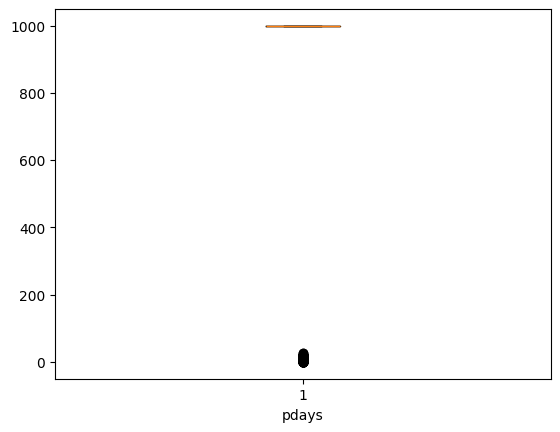

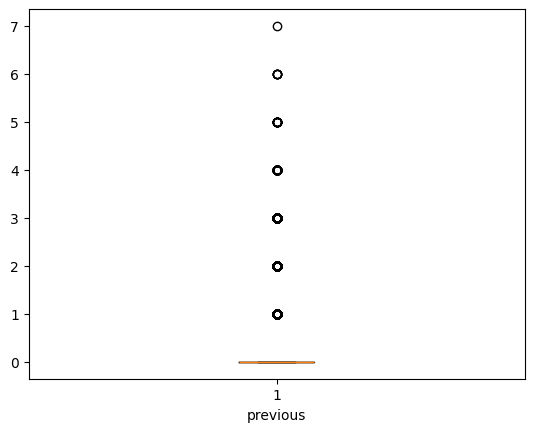

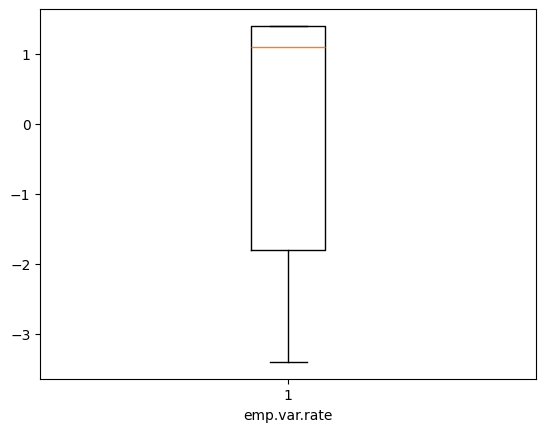

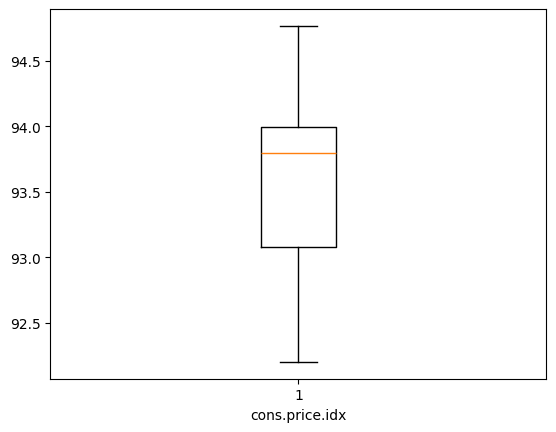

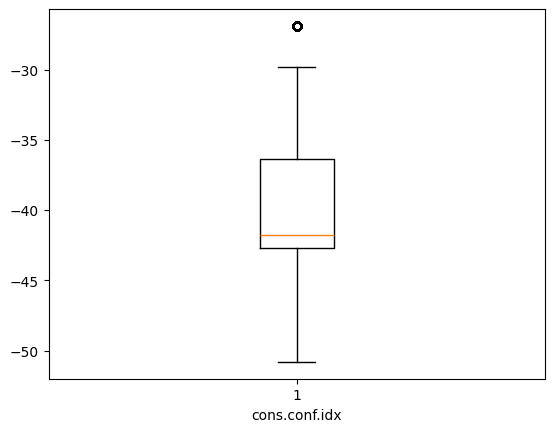

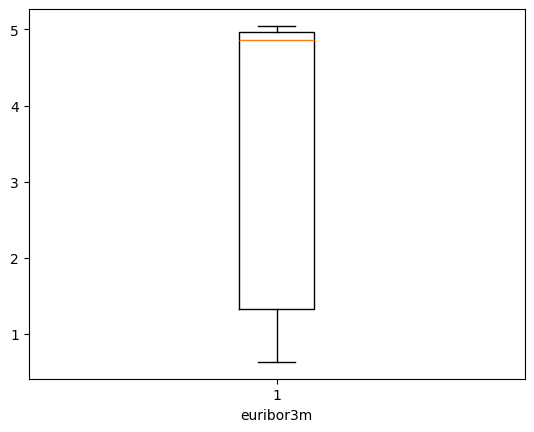

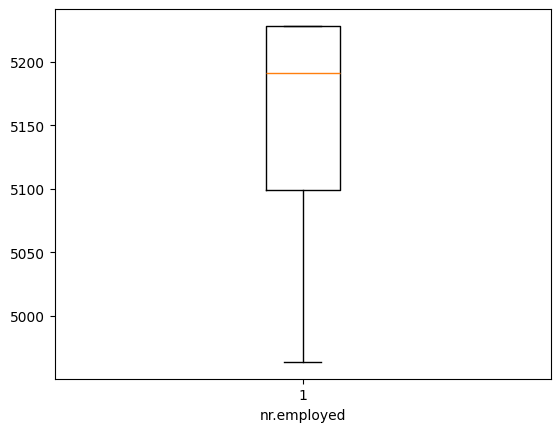

In [ ]:
# Outliers

for col in df.columns:
  if df[col].dtype != 'object':
    plt.boxplot(df[col])
    plt.xlabel(col)
    plt.show()

In [ ]:
df['pdays'].value_counts()

# Everthing is this column is an outliner

,count
pdays,
999,37890
3,438
6,412
4,118
9,64
2,61
7,60
12,58
10,52


In [ ]:
# Outlier removal

out_list = ['age', 'campaign', 'cons.conf.idx']

for col in out_list:
  q1 = df[col].quantile(0.25)
  q3 = df[col].quantile(0.75)

  IQR = q3 - q1

  lb = q1 - (1.5 * IQR)
  ub = q3 + (1.5 * IQR)

  df = df[(df[col] >= lb) & (df[col] <= ub)]

In [ ]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()

for col in df.columns:
  if df[col].dtype == 'object':
    df[col] = LE.fit_transform(df[col])

In [ ]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 36178 entries, 0 to 41186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             36178 non-null  int64  
 1   job             36178 non-null  int64  
 2   marital         36178 non-null  int64  
 3   education       36178 non-null  int64  
 4   default         36178 non-null  int64  
 5   housing         36178 non-null  int64  
 6   loan            36178 non-null  int64  
 7   contact         36178 non-null  int64  
 8   month           36178 non-null  int64  
 9   day_of_week     36178 non-null  int64  
 10  campaign        36178 non-null  int64  
 11  pdays           36178 non-null  int64  
 12  previous        36178 non-null  int64  
 13  poutcome        36178 non-null  int64  
 14  emp.var.rate    36178 non-null  float64
 15  cons.price.idx  36178 non-null  float64
 16  cons.conf.idx   36178 non-null  float64
 17  euribor3m       36178 non-null  floa

In [ ]:
# Correlation

corr_mat = df.corr() # if our data includes object type, we need to include df.corr(numeric_only = True)
corr_mat

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
age,1.000000,-0.018506,-0.388425,-0.097211,0.188718,-0.001729,-0.009060,0.029388,-0.036293,-0.025109,0.005962,0.007390,-0.025933,0.019295,0.075228,0.037307,0.103288,0.086735,0.072747,-0.022390
job,-0.018506,1.000000,0.037164,0.142671,-0.026630,0.006002,-0.010860,-0.023837,-0.032415,-0.001641,-0.009357,-0.026749,0.019729,0.010517,-0.002252,-0.010256,0.046091,-0.002354,-0.012999,0.019792
marital,-0.388425,0.037164,1.000000,0.104102,-0.079582,0.009767,0.007514,-0.058513,-0.008818,0.005343,-0.008823,-0.051401,0.051673,0.004388,-0.101943,-0.060699,-0.033939,-0.110612,-0.110196,0.058802
education,-0.097211,0.142671,0.104102,1.000000,-0.192025,0.014668,0.005004,-0.108438,-0.081262,-0.019656,-0.002219,-0.060958,0.050608,0.020244,-0.062420,-0.085735,0.083066,-0.055083,-0.065208,0.071045
default,0.188718,-0.026630,-0.079582,-0.192025,1.000000,-0.016202,-0.004329,0.134633,-0.010791,-0.006992,0.026083,0.084148,-0.105211,0.021705,0.202589,0.159868,0.046232,0.194718,0.190468,-0.099809
housing,-0.001729,0.006002,0.009767,0.014668,-0.016202,1.000000,0.046522,-0.080323,-0.020244,-0.001833,-0.007063,-0.011997,0.024950,-0.012626,-0.062627,-0.081238,-0.034464,-0.060621,-0.047404,0.012587
loan,-0.009060,-0.010860,0.007514,0.005004,-0.004329,0.046522,1.000000,-0.013360,-0.007946,-0.007160,0.004584,0.003474,-0.005205,-0.000405,0.005342,-0.003723,-0.009031,0.003755,0.007860,-0.007853
contact,0.029388,-0.023837,-0.058513,-0.108438,0.134633,-0.080323,-0.013360,1.000000,0.285346,-0.005089,0.033025,0.120477,-0.221583,0.126426,0.411964,0.603740,0.299958,0.415225,0.279048,-0.148016
month,-0.036293,-0.032415,-0.008818,-0.081262,-0.010791,-0.020244,-0.007946,0.285346,1.000000,0.035691,-0.043945,-0.033845,0.088171,-0.062412,-0.124333,0.037617,-0.030525,-0.069672,-0.173646,-0.028549
day_of_week,-0.025109,-0.001641,0.005343,-0.019656,-0.006992,-0.001833,-0.007160,-0.005089,0.035691,1.000000,-0.049757,-0.011359,-0.003125,0.018630,0.035314,0.008291,0.045487,0.041011,0.029958,0.016365


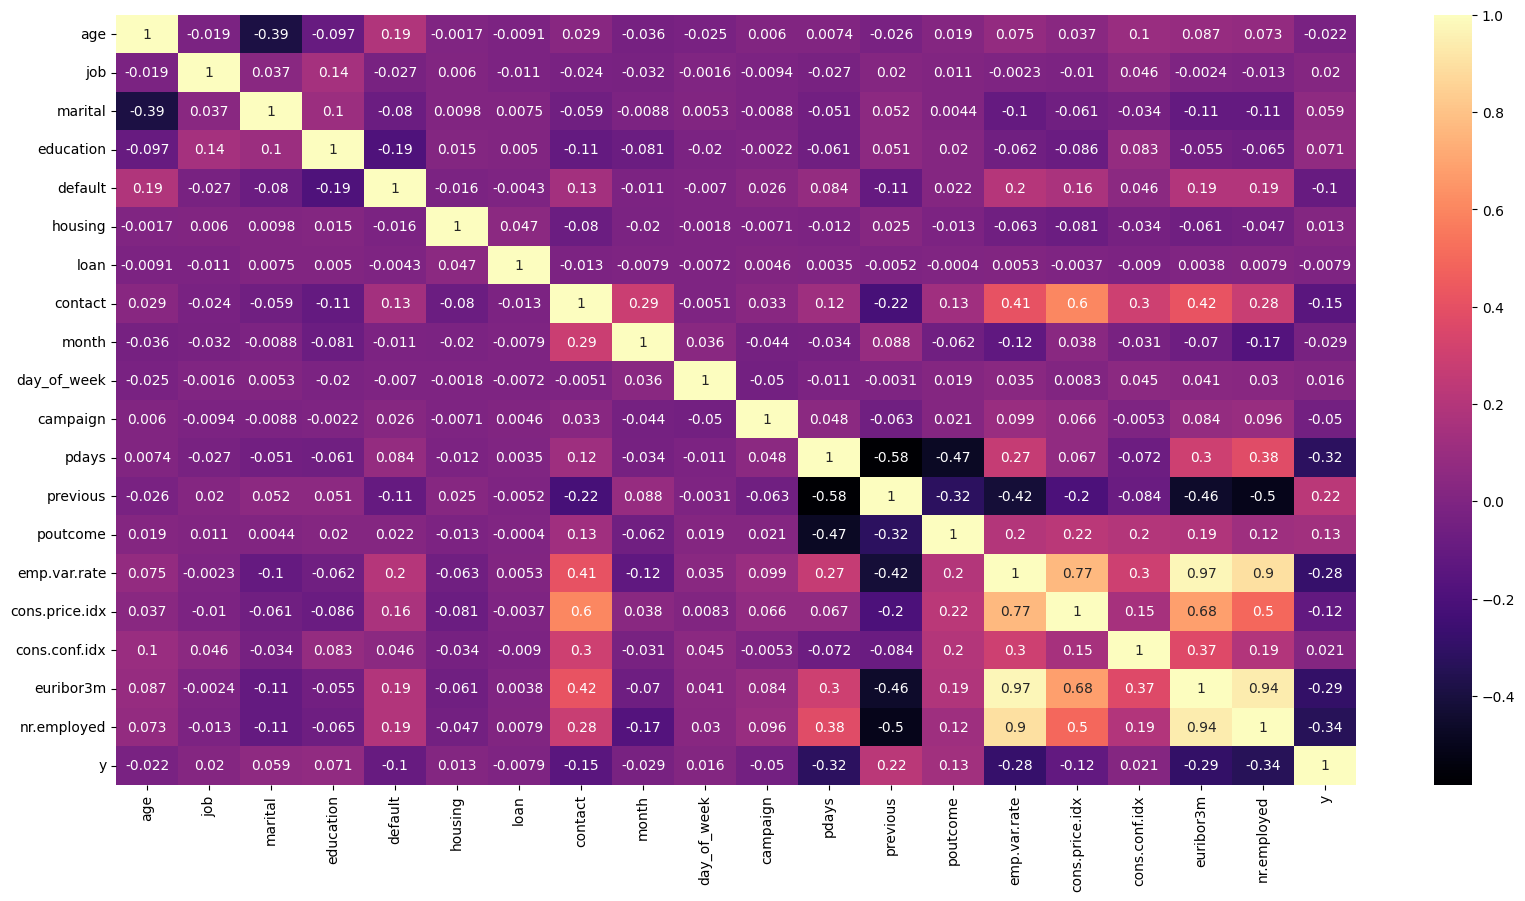

In [ ]:
plt.figure(figsize = (20,10))
sns.heatmap(corr_mat, annot=True, cmap='magma') # annot means annotation
plt.show()

In [ ]:
# VIF: Variance Inflation Factor

x=df.drop('y', axis = 1)  # every column apart from y
y=df['y']                 # only y column

In [ ]:
x


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,56,3,1,0,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
1,57,7,1,3,1,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
2,37,7,1,3,0,2,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
3,40,0,1,1,0,0,0,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
4,56,7,1,3,0,0,2,1,6,1,1,999,0,1,1.1,93.994,-36.4,4.857,5191.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41181,37,0,1,6,0,2,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6
41182,29,10,2,0,0,2,0,0,7,0,1,9,1,2,-1.1,94.767,-50.8,1.028,4963.6
41184,46,1,1,5,0,0,0,0,7,0,1,999,0,1,-1.1,94.767,-50.8,1.028,4963.6
41185,56,5,1,6,0,2,0,0,7,0,2,999,0,1,-1.1,94.767,-50.8,1.028,4963.6


In [ ]:
y

,y
0,0
1,0
2,0
3,0
4,0
...,...
41181,1
41182,0
41184,0
41185,0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_df = pd.DataFrame()


In [ ]:
x.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous',
       'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed'],
      dtype='object')

In [ ]:
vif_df['Features'] = x.columns
vif_df

,Features
0,age
1,job
2,marital
3,education
4,default
5,housing
6,loan
7,contact
8,month
9,day_of_week


In [ ]:
# For every column in x, calculate how strongly it is related to the other columns and put that number
# in the Multicollinearity column of vid_df

vif_df['Multicollinearity'] = [variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,age,21.966070
1,job,2.114551
2,marital,5.649477
3,education,4.533743
4,default,1.413486
5,housing,2.200634
6,loan,1.217609
7,contact,2.935270
8,month,6.604837
9,day_of_week,3.084861


In [ ]:
vif_df = vif_df[vif_df['Features'] != 'nr.employed']
vif_df

,Features,Multicollinearity
0,age,21.966070
1,job,2.114551
2,marital,5.649477
3,education,4.533743
4,default,1.413486
5,housing,2.200634
6,loan,1.217609
7,contact,2.935270
8,month,6.604837
9,day_of_week,3.084861


In [ ]:
# or we can do this

# x.drop('nr.employed', axis =1, inplace = True)
# vif_df=pd.DataFrame()
# vif_df['Features']=x.columns
# vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
# vif_df


In [ ]:
vif_df

,Features,Multicollinearity
0,age,21.966070
1,job,2.114551
2,marital,5.649477
3,education,4.533743
4,default,1.413486
5,housing,2.200634
6,loan,1.217609
7,contact,2.935270
8,month,6.604837
9,day_of_week,3.084861


In [ ]:
#We are going to drop the coloumns until all the multicollinearity are within value 5

In [ ]:
x.drop('nr.employed', axis =1, inplace = True)

In [ ]:
vif_df=pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,age,21.958629
1,job,2.114409
2,marital,5.648510
3,education,4.531664
4,default,1.410297
5,housing,2.200178
6,loan,1.217517
7,contact,2.468746
8,month,5.711382
9,day_of_week,3.084226


In [ ]:
x.drop('cons.conf.idx', axis =1, inplace = True)

In [ ]:
vif_df=pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,age,21.802475
1,job,2.111831
2,marital,5.642321
3,education,4.483496
4,default,1.410095
5,housing,2.199993
6,loan,1.217491
7,contact,2.277468
8,month,5.571438
9,day_of_week,3.079319


In [ ]:
x.drop('euribor3m', axis =1, inplace = True)

In [ ]:
vif_df=pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,age,21.679110
1,job,2.111722
2,marital,5.641153
3,education,4.466134
4,default,1.409482
5,housing,2.199833
6,loan,1.217466
7,contact,2.274155
8,month,5.279932
9,day_of_week,3.077023


In [ ]:
x.drop('pdays', axis = 1, inplace = True)

In [ ]:
vif_df=pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,age,21.676597
1,job,2.111613
2,marital,5.641096
3,education,4.466126
4,default,1.409469
5,housing,2.199554
6,loan,1.217450
7,contact,2.273638
8,month,5.279572
9,day_of_week,3.076970


In [ ]:
x.drop('age', axis = 1, inplace = True)

In [ ]:
vif_df=pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,job,2.111599
1,marital,4.836284
2,education,4.460385
3,default,1.373118
4,housing,2.199499
5,loan,1.217398
6,contact,2.273044
7,month,5.272007
8,day_of_week,3.075234
9,campaign,3.638135


In [ ]:
x.drop('poutcome', axis =1 , inplace = True)

In [ ]:
vif_df=pd.DataFrame()
vif_df['Features']=x.columns
vif_df['Multicollinearity']=[variance_inflation_factor(x.values, i) for i in range(len(x.columns))]
vif_df

,Features,Multicollinearity
0,job,2.111383
1,marital,4.833896
2,education,4.455227
3,default,1.372542
4,housing,2.199498
5,loan,1.217391
6,contact,2.267549
7,month,5.261205
8,day_of_week,3.074203
9,campaign,3.637999


# Model Building

In [ ]:
# Model Building

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.30)

In [ ]:
x_train

,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,emp.var.rate,cons.price.idx
26012,0,1,6,0,2,0,0,7,4,2,0,-0.1,93.200
31382,7,1,3,1,1,1,0,6,4,2,0,-1.8,92.893
35208,0,1,2,1,2,0,0,6,0,2,1,-1.8,92.893
3502,1,1,2,0,1,1,1,6,2,3,0,1.1,93.994
33203,1,2,0,0,0,0,0,6,3,2,1,-1.8,92.893
...,...,...,...,...,...,...,...,...,...,...,...,...,...
35330,0,2,3,0,0,0,0,6,0,3,1,-1.8,92.893
35520,0,1,3,0,2,0,0,6,1,1,0,-1.8,92.893
39931,9,2,6,0,2,2,0,4,2,1,0,-1.7,94.055
20960,9,1,6,0,0,0,0,1,2,2,0,1.4,93.444


In [ ]:
x_test

,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,previous,emp.var.rate,cons.price.idx
37346,2,1,6,0,2,0,0,1,3,1,1,-2.9,92.201
30378,6,2,6,0,2,0,1,0,2,1,0,-1.8,93.075
38945,5,1,0,0,0,0,1,7,0,4,1,-3.4,92.649
34882,0,1,1,0,2,0,0,6,0,6,1,-1.8,92.893
35170,1,1,2,1,2,0,0,6,0,1,1,-1.8,92.893
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32615,8,2,3,0,2,0,0,6,1,1,0,-1.8,92.893
13383,1,1,2,0,2,0,0,3,4,1,0,1.4,93.918
31256,0,2,6,0,2,0,0,6,4,1,0,-1.8,92.893
559,1,1,1,1,2,2,1,6,3,1,0,1.1,93.994


In [ ]:
y_train

,y
26012,0
31382,0
35208,0
3502,0
33203,0
...,...
35330,0
35520,0
39931,0
20960,0


In [ ]:
y_test

,y
37346,0
30378,0
38945,0
34882,0
35170,0
...,...
32615,0
13383,0
31256,0
559,0


In [ ]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()

lr.fit(x_train,y_train)


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Evaluation

In [ ]:
y_predict=lr.predict(x_test)

In [ ]:
from sklearn.metrics import *

accuracy_score(y_test,y_predict)*100

88.68619863644739

In [ ]:
cf = confusion_matrix(y_test,y_predict)
cf

array([[9586,   37],
       [1191,   40]])

<function matplotlib.pyplot.show(close=None, block=None)>

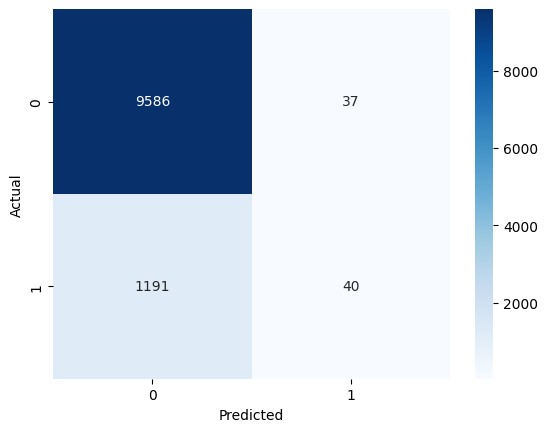

In [ ]:
sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')   # fmt = d to remove the exponent value (fmt -> format, d -> decimal point)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show

In [ ]:
# precision: Of all the items the model predicted as positive, how may were actually positive
# recall: of all the items that are actually postive, how may did the model predict correctly
# f1-score: A single score that balances Precision and Recall using their harmonic mean

In [ ]:
print(classification_report(y_test,y_predict))

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      9623
           1       0.52      0.03      0.06      1231

    accuracy                           0.89     10854
   macro avg       0.70      0.51      0.50     10854
weighted avg       0.85      0.89      0.84     10854

